
Loading image: 512 x 512
CPU time: 1.293154 sec
GPU time: 0.000091 sec
Speedup: 14163.79x


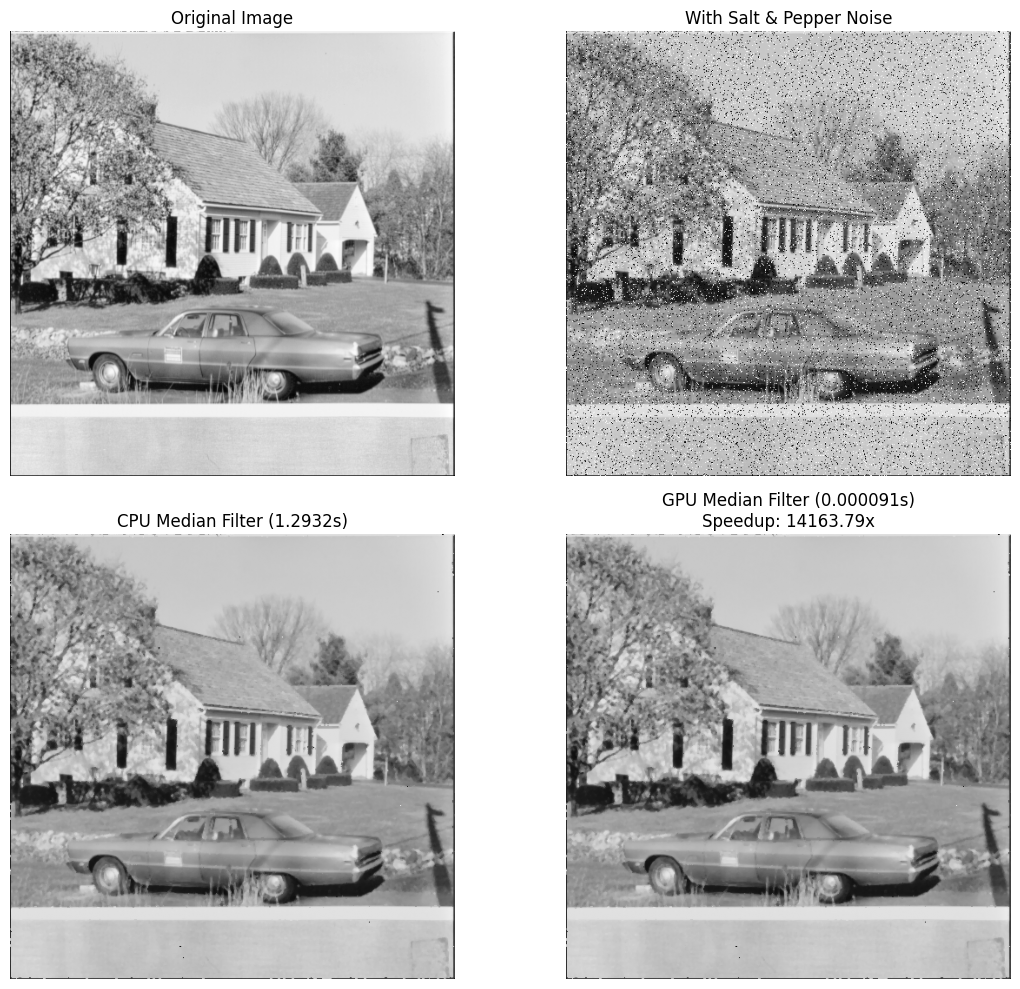

In [9]:
import numpy as np
import pycuda.autoinit
import pycuda.driver as cuda
from pycuda.compiler import SourceModule
import time
import matplotlib.pyplot as plt
from PIL import Image
import os
import warnings
warnings.filterwarnings('ignore')


kernel_code = """
__global__ void medianFilter3x3(unsigned char* input, unsigned char* output, int width, int height) {
    int x = blockIdx.x * blockDim.x + threadIdx.x;
    int y = blockIdx.y * blockDim.y + threadIdx.y;
    
    if (x >= width || y >= height) return;
    
    unsigned char pixels[9];
    int idx = 0;
    
    for (int dy = -1; dy <= 1; dy++) {
        for (int dx = -1; dx <= 1; dx++) {
            int nx = x + dx;
            int ny = y + dy;
            
            if (nx < 0) nx = 0;
            if (nx >= width) nx = width - 1;
            if (ny < 0) ny = 0;
            if (ny >= height) ny = height - 1;
            
            pixels[idx++] = input[ny * width + nx];
        }
    }
    
    for (int i = 1; i < 9; i++) {
        unsigned char key = pixels[i];
        int j = i - 1;
        while (j >= 0 && pixels[j] > key) {
            pixels[j + 1] = pixels[j];
            j--;
        }
        pixels[j + 1] = key;
    }
    
    output[y * width + x] = pixels[4];
}
"""

def add_salt_pepper_noise(image, salt_prob=0.05, pepper_prob=0.05):
    noisy = image.copy()
    h, w = image.shape
    
    num_salt = int(h * w * salt_prob)
    for _ in range(num_salt):
        y = np.random.randint(0, h)
        x = np.random.randint(0, w)
        noisy[y, x] = 255
    
    num_pepper = int(h * w * pepper_prob)
    for _ in range(num_pepper):
        y = np.random.randint(0, h)
        x = np.random.randint(0, w)
        noisy[y, x] = 0
    
    return noisy

def load_image(path):
    img = Image.open(path).convert('L')
    return np.array(img, dtype=np.uint8)

def save_image(array, path):
    img = Image.fromarray(array.astype(np.uint8), mode='L')
    img.save(path)

def apply_median_filter_gpu(image, block_size=16):
    h, w = image.shape
    image_flat = image.flatten().astype(np.uint8)
    
    input_gpu = cuda.mem_alloc(h * w)
    output_gpu = cuda.mem_alloc(h * w)
    
    cuda.memcpy_htod(input_gpu, image_flat)
    
    mod = SourceModule(kernel_code)
    median_filter = mod.get_function("medianFilter3x3")
    
    grid_x = (w + block_size - 1) // block_size
    grid_y = (h + block_size - 1) // block_size
    
    
    median_filter(
        input_gpu, output_gpu,
        np.int32(w), np.int32(h),
        block=(block_size, block_size, 1),
        grid=(grid_x, grid_y)
    )
    cuda.Context.synchronize()
    
    start = time.perf_counter()
    
    median_filter(
        input_gpu, output_gpu,
        np.int32(w), np.int32(h),
        block=(block_size, block_size, 1),
        grid=(grid_x, grid_y)
    )
    
    cuda.Context.synchronize()
    end = time.perf_counter()
    
    output_flat = np.empty(h * w, dtype=np.uint8)
    cuda.memcpy_dtoh(output_flat, output_gpu)
    
    input_gpu.free()
    output_gpu.free()
    
    return output_flat.reshape(h, w), end - start

def apply_median_filter_cpu(image):
    h, w = image.shape
    output = np.zeros_like(image)
    
    start = time.perf_counter()
    
    for y in range(h):
        for x in range(w):
            pixels = []
            for dy in (-1, 0, 1):
                for dx in (-1, 0, 1):
                    ny = max(0, min(y + dy, h - 1))
                    nx = max(0, min(x + dx, w - 1))
                    pixels.append(image[ny, nx])
            pixels.sort()
            output[y, x] = pixels[4]
    
    end = time.perf_counter()
    return output, end - start


INPUT_IMAGE_PATH = "Car.bmp"

original = load_image(INPUT_IMAGE_PATH)
h, w = original.shape
print(f"\nLoading image: {w} x {h}")

noisy = add_salt_pepper_noise(original, salt_prob=0.05, pepper_prob=0.05)
save_image(noisy, "noisy_image.bmp")

cpu_result, cpu_time = apply_median_filter_cpu(noisy)
print(f"CPU time: {cpu_time:.6f} sec")
save_image(cpu_result, "cpu_result.bmp")

gpu_result, gpu_time = apply_median_filter_gpu(noisy)
print(f"GPU time: {gpu_time:.6f} sec")
save_image(gpu_result, "gpu_result.bmp")

speedup = cpu_time / gpu_time
print(f"Speedup: {speedup:.2f}x")

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

axes[0, 0].imshow(original, cmap='gray')
axes[0, 0].set_title('Original Image')
axes[0, 0].axis('off')

axes[0, 1].imshow(noisy, cmap='gray')
axes[0, 1].set_title('With Salt & Pepper Noise')
axes[0, 1].axis('off')

axes[1, 0].imshow(cpu_result, cmap='gray')
axes[1, 0].set_title(f'CPU Median Filter ({cpu_time:.4f}s)')
axes[1, 0].axis('off')

axes[1, 1].imshow(gpu_result, cmap='gray')
axes[1, 1].set_title(f'GPU Median Filter ({gpu_time:.6f}s)\nSpeedup: {speedup:.2f}x')
axes[1, 1].axis('off')

plt.tight_layout()
plt.savefig('median_filter_results.png', dpi=150)
plt.show()